# Neural Posterior Estimation (NPE) Example
Breck Meagher   
(04/22/2026)

In a glossing-over way, this notebook shows you how to do Bayesian inference without writing down a likelihood explicitly. Instead, you:

1. Sample parameters θ from a prior (your initial belief).
2. Then use a simulator to generate data x that would be observed if those parameters were true.
3. This gives you many pairs (θ,x), which act like training data.

A neural network is then trained to reverse this process: given an observation x, it learns to predict a distribution over possible parameters θ that could have produced it. That learned distribution is the posterior.

The key idea of Neural Posterior Estimation is that once this network is trained, you can plug in a new observation and instantly get an approximate posterior—no expensive sampling or analytic math required.

## Gaussian Example

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

### 1. Define Prior and Simulator

In [2]:
def sample_prior(n):
    return torch.randn(n, 1)  # theta ~ N(0,1)

def simulator(theta):
    return theta + torch.randn_like(theta)  # x ~ N(theta, 1)

### 2. Generate Training Data
In NPE, we simulate pairs (θ,x):

In [3]:
N = 10000

theta = sample_prior(N)
x = simulator(theta)

### 3. Define Neural Density Estimator

We model q$_\phi$(θ∣x) as a Gaussian with NN-predicted mean and variance.

In [4]:
class PosteriorNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
        )
        self.mean = nn.Linear(64, 1)
        self.log_std = nn.Linear(64, 1)

    def forward(self, x):
        h = self.net(x)
        mu = self.mean(h)
        log_std = self.log_std(h)
        std = torch.exp(log_std)
        return mu, std

### 4. Loss Function (Maximum Likelihood)

We maximize:
$$
\log (q_\phi | x)
$$

In [5]:
def loss_fn(mu, std, theta):
    dist = torch.distributions.Normal(mu, std)
    return -dist.log_prob(theta).mean()

### 5. Train the Network

In [6]:
model = PosteriorNet()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(2000):
    optimizer.zero_grad()
    
    mu, std = model(x)
    loss = loss_fn(mu, std, theta)
    
    loss.backward()
    optimizer.step()
    
    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 1.4377
Epoch 200, Loss: 1.0825
Epoch 400, Loss: 1.0820
Epoch 600, Loss: 1.0815
Epoch 800, Loss: 1.0811
Epoch 1000, Loss: 1.0807
Epoch 1200, Loss: 1.0803
Epoch 1400, Loss: 1.0800
Epoch 1600, Loss: 1.0797
Epoch 1800, Loss: 1.0794


### 6. Evaluate Posterior

Pick an observation $x_0$, and compare:

* learned posterior
* true posterior (analytical)

For this model:
$$
p(\theta∣x)=\mathcal{N}(\frac{x}{2},\frac{1}{2})
$$

In [11]:
x0 = torch.tensor([[2.0]])

mu, std = model(x0)

# learned posterior
dist = torch.distributions.Normal(mu, std)
theta_samples = dist.sample((1000,)).squeeze()

# true posterior
true_mu = x0 / 2
true_std = (0.5)**0.5
dist_true = torch.distributions.Normal(true_mu, true_std)
true_samples = dist_true.sample((1000,)).squeeze()

### 7. Plot Comparison

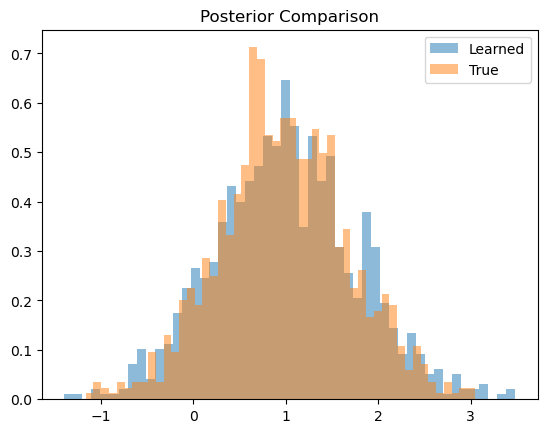

In [12]:
plt.hist(theta_samples.detach().numpy(), bins=50, density=True, alpha=0.5, label="Learned")
plt.hist(true_samples.detach().numpy(), bins=50, density=True, alpha=0.5, label="True")
plt.legend()
plt.title("Posterior Comparison")
plt.show()

## Noisy Sine Wave Example

In [15]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

np.random.seed(0)
torch.manual_seed(0)

### Simulator (generate training data)

In [16]:
def simulate_sine(theta, t):
    A, w, phi = theta
    return A * np.sin(w * t + phi)

def sample_theta():
    A = np.random.uniform(0.5, 2.0)
    w = np.random.uniform(0.5, 3.0)
    phi = np.random.uniform(0, 2*np.pi)
    return np.array([A, w, phi])

### Generate Dataset (NPE training step)
Create many pairs (x,θ).

In [17]:
N = 20000
T = 50
t = np.linspace(0, 1, T)

X = []
THETA = []

noise_sigma = 0.2

for _ in range(N):
    theta = sample_theta()
    clean = simulate_sine(theta, t)
    x = clean + np.random.normal(0, noise_sigma, size=T)
    
    X.append(x)
    THETA.append(theta)

X = np.array(X)
THETA = np.array(THETA)

### Visualize a few samples

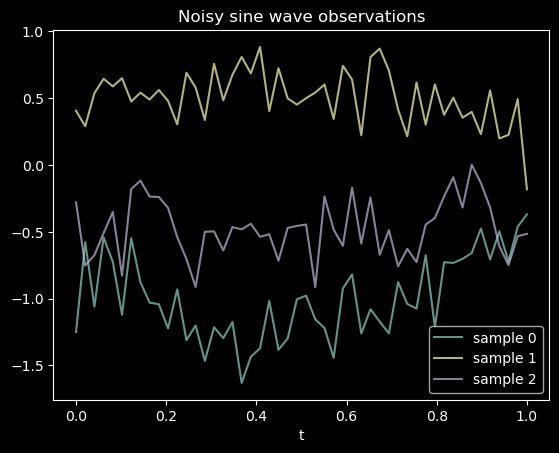

In [27]:
plt.style.use("dark_background")
plt.figure()

for i in range(3):
    plt.plot(t, X[i], alpha=0.7, label=f"sample {i}")

plt.title("Noisy sine wave observations")
plt.xlabel("t")
plt.legend()
plt.show()

### Neural Posterior Model q$_\phi$($\theta \mid x$)
Simple MLP that maps a waveform → Gaussian parameters.

In [19]:
class PosteriorNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(T, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
        )
        self.mu = nn.Linear(128, 3)
        self.log_sigma = nn.Linear(128, 3)

    def forward(self, x):
        h = self.net(x)
        mu = self.mu(h)
        sigma = torch.exp(self.log_sigma(h))
        return mu, sigma

### Train (Amortized inference)
Maximize:
$$
\log (q_\phi | x)
$$

In [22]:
model = PosteriorNet()
opt = optim.Adam(model.parameters(), lr=1e-3)

X_t = torch.tensor(X, dtype=torch.float32)
THETA_t = torch.tensor(THETA, dtype=torch.float32)

losses = []

for epoch in range(1000):
    mu, sigma = model(X_t)
    
    dist = torch.distributions.Normal(mu, sigma)
    loss = -dist.log_prob(THETA_t).sum(dim=1).mean()
    
    opt.zero_grad()
    loss.backward()
    opt.step()
    
    losses.append(loss.item())

    if epoch % 100 == 0:
        print(epoch, loss.item())

0 11.8953218460083
100 1.7616740465164185
200 0.3524068295955658
300 -0.11823062598705292
400 -0.5215878486633301
500 -0.7328755259513855
600 -0.6555209755897522
700 -0.9922685623168945
800 -1.062796950340271
900 -1.1340980529785156


### Training curve

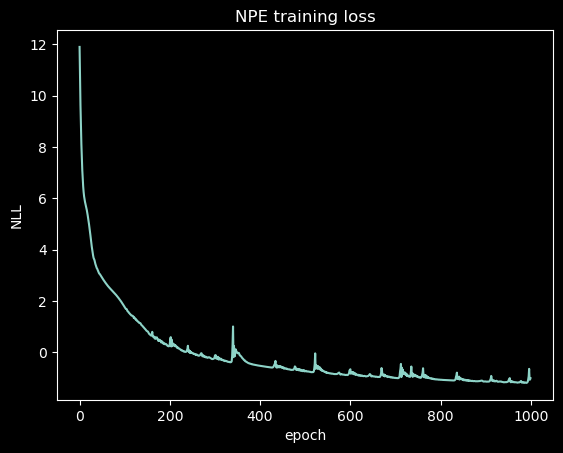

In [31]:
plt.plot(losses)
plt.title("NPE training loss")
plt.xlabel("epoch")
plt.ylabel("NLL")
plt.show()

### Inference on a new observation
Generate a “true system” and recover parameters.

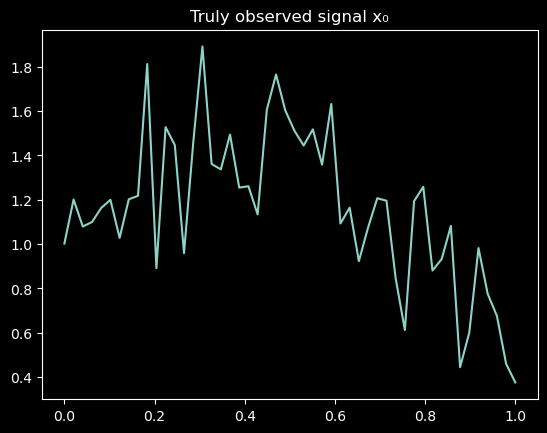

In [33]:
true_theta = np.array([1.5, 2.2, 0.7])

x_obs = simulate_sine(true_theta, t)
x_obs_noisy = x_obs + np.random.normal(0, noise_sigma, size=T)

plt.plot(t, x_obs_noisy)
plt.title("Truly observed signal x₀")
plt.show()

### Posterior prediction

In [25]:
x_input = torch.tensor(x_obs_noisy, dtype=torch.float32).unsqueeze(0)

mu, sigma = model(x_input)

print("Predicted mean:", mu.detach().numpy())
print("Predicted std:", sigma.detach().numpy())
print("True theta:", true_theta)

Predicted mean: [[1.5190679  2.4574962  0.47489697]]
Predicted std: [[0.03780277 0.12471446 0.11515729]]
True theta: [1.5 2.2 0.7]


### Sample posterior

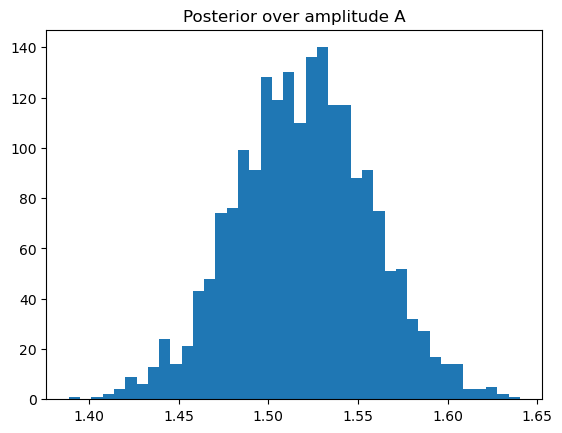

In [26]:
samples = np.random.normal(mu.detach().numpy(), sigma.detach().numpy(), size=(2000, 3))

plt.figure()
plt.hist(samples[:, 0], bins=40)
plt.title("Posterior over amplitude A")
plt.show()

In [36]:
import pandas as pd

pred_theta = mu.detach().numpy().squeeze()
pred_sigma = sigma.detach().numpy().squeeze()

true_theta = np.array(true_theta)

abs_error = np.abs(pred_theta - true_theta)

df = pd.DataFrame({
    "Parameter": ["Amplitude (A)", "Frequency (ω)", "Phase (φ)"],
    "True Value": np.round(true_theta, 3),
    "Predicted Mean": np.round(pred_theta, 3),
    "Std Dev (Uncertainty)": np.round(pred_sigma, 3),
    "Absolute Error": np.round(abs_error, 3)
})

df

,Parameter,True Value,Predicted Mean,Std Dev (Uncertainty),Absolute Error
0,Amplitude (A),1.5,1.519,0.038,0.019
1,Frequency (ω),2.2,2.457,0.125,0.257
2,Phase (φ),0.7,0.475,0.115,0.225
